In [1]:
# makes more of things u give it
# lets load up a bunch of names from ./makemore/names.txt
path = './makemore/names.txt'
words = open(path, 'r').read().splitlines()
print('first 10 words: \t', words[:10],
      '\nnumber of words: \t', len(words),
      '\nsmallest word length: \t', min(len(w) for w in words),
      '\nbiggest word length: \t', max(len(w) for w in words))

first 10 words: 	 ['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia', 'harper', 'evelyn'] 
number of words: 	 32033 
smallest word length: 	 2 
biggest word length: 	 15


In [2]:
print('bigrams of first word')
for w in words[:1]:
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)
        
print('\nbigrams of second word')
for w in words[1:2]:
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)

bigrams of first word
e m
m m
m a

bigrams of second word
o l
l i
i v
v i
i a


In [3]:
# lets hallucinate a hidden start and end bigram
for w in words[:1]:
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        print(c1,c2)

<S> e
e m
m m
m a
a <E>


In [4]:
# lets start counting occurrences (frequency of bigrams)
bfreq = {}
for w in words[:3]: # first 3 words
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        bigram = (c1,c2)
        bfreq[bigram] = bfreq.get(bigram, 0) + 1
        # print(c1,c2)

print(bfreq) # notice that bigram ('a', '<E>') occurs 3 times. Means that all 3 names ended with a's.
print(words[:3])

{('<S>', 'e'): 1, ('e', 'm'): 1, ('m', 'm'): 1, ('m', 'a'): 1, ('a', '<E>'): 3, ('<S>', 'o'): 1, ('o', 'l'): 1, ('l', 'i'): 1, ('i', 'v'): 1, ('v', 'i'): 1, ('i', 'a'): 1, ('<S>', 'a'): 1, ('a', 'v'): 1, ('v', 'a'): 1}
['emma', 'olivia', 'ava']


In [5]:
# lets calc for all words
bfreq = {}
for w in words:
    w = ['<S>'] + list(w) + ['<E>']
    for c1, c2 in zip(w, w[1:]):
        bigram = (c1,c2)
        bfreq[bigram] = bfreq.get(bigram, 0) + 1

In [6]:
# lets look into the bigrams
# reverse sort em
bfreq_sorted = sorted(bfreq.items(), key = lambda kv: -kv[1])
bfreq_sorted[:10]

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963)]

In [7]:
# lets get it into a pytorch tensor

import torch
alphabet = ['.'] + sorted(list(set(''.join(words))))
print(alphabet)
N = len(alphabet)  # 27 = a-z + 1 special char #OLD 28 == Alphabet + two special encodings for start and end
M = N
shape = (N, M)
tensor = torch.zeros(shape, dtype=torch.int32)
tensor.shape

# create a reverse LUT for future use
# alphabet.index('a') # dont do this , create a lookup table for O(1)

atoi = { v:i for i,v in enumerate(alphabet) }
print(atoi)

['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
{'.': 0, 'a': 1, 'b': 2, 'c': 3, 'd': 4, 'e': 5, 'f': 6, 'g': 7, 'h': 8, 'i': 9, 'j': 10, 'k': 11, 'l': 12, 'm': 13, 'n': 14, 'o': 15, 'p': 16, 'q': 17, 'r': 18, 's': 19, 't': 20, 'u': 21, 'v': 22, 'w': 23, 'x': 24, 'y': 25, 'z': 26}


In [8]:
# lets put it into this tensor we created
for w in words:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        bigram = (c1,c2)
        tensor[atoi_c1, atoi_c2] += 1



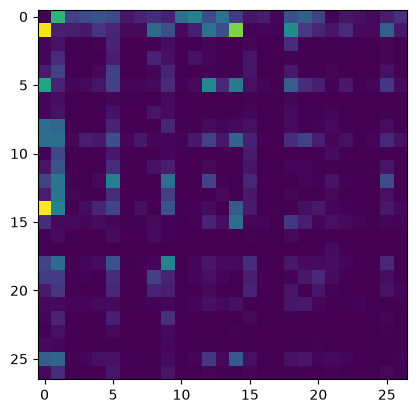

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.imshow(tensor)

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

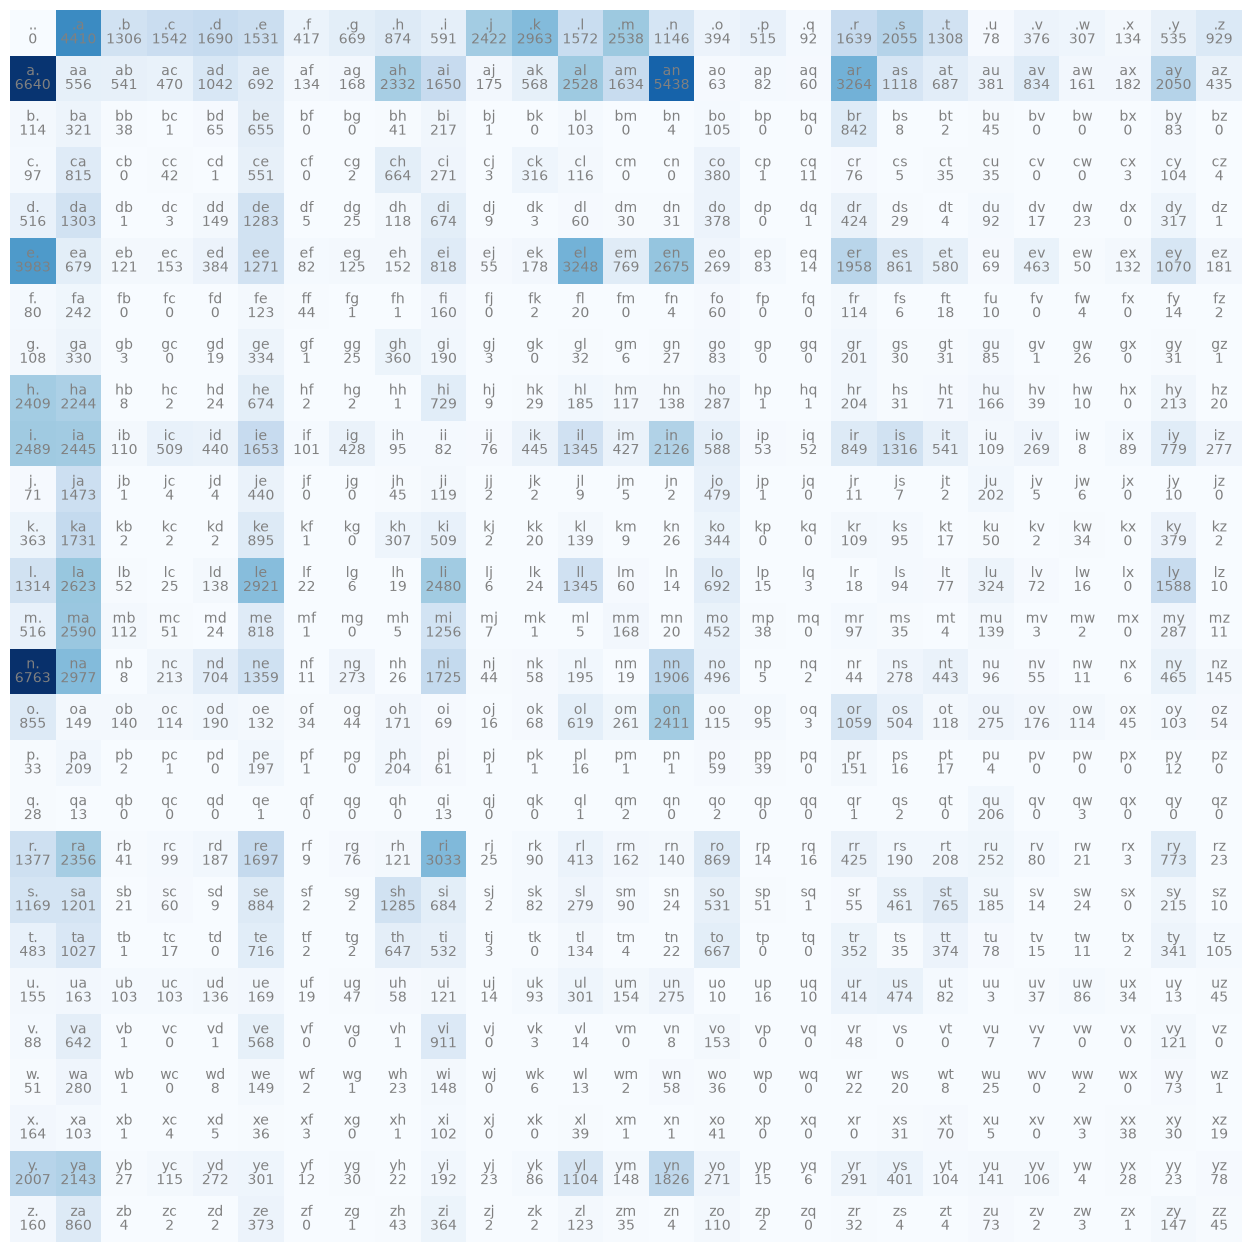

In [10]:
plt.figure(figsize=(16,16))
plt.imshow(tensor, cmap='Blues')
for i in range(N):
    for j in range(N):
        chstr = alphabet[i] + alphabet[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, tensor[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off')
        

In [11]:
print(f'tensor: {tensor[0].tolist()}')
print(f'alphabet: {alphabet}')

tensor: [0, 4410, 1306, 1542, 1690, 1531, 417, 669, 874, 591, 2422, 2963, 1572, 2538, 1146, 394, 515, 92, 1639, 2055, 1308, 78, 376, 307, 134, 535, 929]
alphabet: ['.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


In [12]:
# Side-Lesson
print("Torch Multinomial 101")
print("=====================")
# sample from this distribution
# distribution is set that all the probabilities in p sum to 1.0
g = torch.Generator().manual_seed(2147483647)
p = torch.rand(3, generator=g)
p = p / p.sum()
print(p)
#torch.multinomial(p)
print("This means that there is a:\n0.6061 prob of getting 0\n0.3033 prob of getting 1\n0.0903 prob of getting 2")
# sample 20 from our prob distribution
torch.multinomial(p, num_samples=20, replacement=True, generator=g)
print("Sampling 20 samples from this prob distribution")

Torch Multinomial 101
tensor([0.6064, 0.3033, 0.0903])
This means that there is a:
0.6061 prob of getting 0
0.3033 prob of getting 1
0.0903 prob of getting 2
Sampling 20 samples from this prob distribution


In [13]:
# Predicting next letter ---
# back to our 'tensor' tensor with the actual probabilities
# convert to probabilities
p = tensor[0].float()
p = p / p.sum()
p
g = torch.Generator().manual_seed(2147483647)
#torch.multinomial(p, num_samples=2, replacement=True, generator=g)
# found out that num_samples=1 result is NOT the same as num_samples=2 slice first element b/c of underlying impl

# get first character
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print('first character: ', alphabet[ix]) # should be j
# now we need to look at the 'j' row, and sample its probabilities
p = tensor[ix].float()
p = p / p.sum()
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
print('next character after: ', alphabet[ix])
# repeat this logic to generate words!


first character:  c
next character after:  e


In [14]:
# THE Following is a pre-computed optimization, u can skip to the next cell if reviewing...
P = tensor.float()
print(f'P first 5 {(P[0][:5]).tolist()}')
P_sums = P.sum(1, keepdim=True) 
# P_sums = P.sum(-1, keepdim=True)  # same as above but Karpathy says its just coincidence
# ... because sums accross the rows horizontally or vertically is identical.
# ... but we WANT TO sum across the rows horizontally. (1,keepdim=True)
#P_sums = torch.sum(P,-1, keepdim=True) # same as above
# P = P / P_sums # Broadcasting Rules, Broadcasting Semantics 
P /= P_sums # potentially faster than above


P first 5 [0.0, 4410.0, 1306.0, 1542.0, 1690.0]


In [15]:
# Generating words
g = torch.Generator().manual_seed(2147483647)
wordz = []
for i in range(20):
    ix = 0
    word = ""
    while True:
        #innefficient , use matrix P (define above)
        #p = tensor[ix].float()
        #p = p / p.sum()
        
        #p = torch.ones(27) / 27 # sanity check

        p = P[ix]
        
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        word += alphabet[ix]
    wordz.append(word)
print(wordz)
    



['cexze', 'momasurailezitynn', 'konimittain', 'llayn', 'ka', 'da', 'staiyaubrtthrigotai', 'moliellavo', 'ke', 'teda', 'ka', 'emimmsade', 'enkaviyny', 'ftlspihinivenvorhlasu', 'dsor', 'br', 'jol', 'pen', 'aisan', 'ja']


In [16]:
# resume at 51:30

for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        print(f'{c1}{c2}: {prob:.4f}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


In [17]:
# if everything was equally likely , it would be 1/27
print(f'{1/27:.4f}')

0.0370


In [18]:
# The liklihood is the product of all the probabilities

liklihood = 1
for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        liklihood *= prob
        print(f'{c1}{c2}: {prob:.4f}')
print(f'liklihood: {liklihood}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960
liklihood: 1.4309086396644506e-17


In [19]:
# People want to use log(liklihood) instead

liklihood = 1
log_liklihood = 0.0

for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        print(f'{c1}{c2}: {prob:.4f}, logprob: {logprob:.4f}')
print(f'liklihood: {liklihood}')
print(f'log_liklihood: {log_liklihood}')

# logs let you do log(a * b * c) = log(a) + log(b) + log(c)
# Which lets you accumulate, rather than multiply

.e: 0.0478, logprob: -3.0408
em: 0.0377, logprob: -3.2793
mm: 0.0253, logprob: -3.6772
ma: 0.3899, logprob: -0.9418
a.: 0.1960, logprob: -1.6299
.o: 0.0123, logprob: -4.3982
ol: 0.0780, logprob: -2.5508
li: 0.1777, logprob: -1.7278
iv: 0.0152, logprob: -4.1867
vi: 0.3541, logprob: -1.0383
ia: 0.1381, logprob: -1.9796
a.: 0.1960, logprob: -1.6299
.a: 0.1377, logprob: -1.9829
av: 0.0246, logprob: -3.7045
va: 0.2495, logprob: -1.3882
a.: 0.1960, logprob: -1.6299
liklihood: 1.4309086396644506e-17
log_liklihood: -38.78563690185547


In [20]:
# but people also like:
# 1. a loss function when 0 == good, 
# 2. a normalized number, so they average out the number

liklihood = 1
log_liklihood = 0.0
n = 0

for w in words[:3]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        n += 1
        print(f'{c1}{c2}: {prob:.4f}, logprob: {logprob:.4f}')
print(f'liklihood: {liklihood}')
print(f'log_liklihood: {log_liklihood}')
print(f'negative log_liklihood: {-log_liklihood}')
print(f'average negative log likelihood: {-log_liklihood/n}')

# The lower this is, the better we are. Low loss == good.




.e: 0.0478, logprob: -3.0408
em: 0.0377, logprob: -3.2793
mm: 0.0253, logprob: -3.6772
ma: 0.3899, logprob: -0.9418
a.: 0.1960, logprob: -1.6299
.o: 0.0123, logprob: -4.3982
ol: 0.0780, logprob: -2.5508
li: 0.1777, logprob: -1.7278
iv: 0.0152, logprob: -4.1867
vi: 0.3541, logprob: -1.0383
ia: 0.1381, logprob: -1.9796
a.: 0.1960, logprob: -1.6299
.a: 0.1377, logprob: -1.9829
av: 0.0246, logprob: -3.7045
va: 0.2495, logprob: -1.3882
a.: 0.1960, logprob: -1.6299
liklihood: 1.4309086396644506e-17
log_liklihood: -38.78563690185547
negative log_liklihood: 38.78563690185547
average negative log likelihood: 2.424102306365967


In [21]:
# Happy w/ 3b1b - cross entropy video that came out recently. 

# Likelihood of a word.
liklihood = 1
log_liklihood = 0.0
n = 0

for w in ["andrej"]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        n += 1
        print(f'{c1}{c2}: {prob:.4f}, logprob: {logprob:.4f}')
print(f'{log_liklihood=}')
print(f'likelihood of "andrej": {-log_liklihood/n}')


# Dont forget to reset
liklihood = 1
log_liklihood = 0.0
n = 0

name = "mario"
for w in [name]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        n += 1
print(f'likelihood of "{name}": {-log_liklihood/n}')




.a: 0.1377, logprob: -1.9829
an: 0.1605, logprob: -1.8296
nd: 0.0384, logprob: -3.2594
dr: 0.0771, logprob: -2.5620
re: 0.1336, logprob: -2.0127
ej: 0.0027, logprob: -5.9171
j.: 0.0245, logprob: -3.7098
log_liklihood=tensor(-21.2735)
likelihood of "andrej": 3.03906512260437
likelihood of "mario": 2.1469457149505615


In [22]:
# Model Smoothing

# Dont forget to reset
liklihood = 1
log_liklihood = 0.0
n = 0

name = "marioqq"
for w in [name]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        n += 1
        print(f'{c1}{c2}: {prob:.4f}, logprob: {logprob:.4f}')
print(f'likelihood of "{name}": {-log_liklihood/n}')
print('====================================================\n')
print('Notice \'qq\' bigram, Looks like we get infinite probablity of it occurring')
print("we fix that with \'model smoothing\'")

# Q: what is model smoothing?
# A: You increment all the n-gram probabilities by some constant.

# how to do 'model smoothing'

# The big tensor P, add +1 to it. Distributes +1 to all the values. Eliminating small numbers.




.m: 0.0792, logprob: -2.5354
ma: 0.3899, logprob: -0.9418
ar: 0.0963, logprob: -2.3400
ri: 0.2388, logprob: -1.4320
io: 0.0332, logprob: -3.4046
oq: 0.0004, logprob: -7.8803
qq: 0.0000, logprob: -inf
q.: 0.1029, logprob: -2.2736
likelihood of "marioqq": inf

Notice 'qq' bigram, Looks like we get infinite probablity of it occurring
we fix that with 'model smoothing'


In [23]:
## Recalcualte P for model smoothing
P = tensor.float()
print(f'MODEL SMOOTHING before   {(P[0][:5]).tolist()}')
print(f'MODEL SMOOTHING after    {(tensor + 1).float()[0][:5].tolist()}')
P = P+1
print(f'MODEL SMOOTHING v2 after {(P).float()[0][:5].tolist()}')
P_sums = P.sum(1, keepdim=True) 
P /= P_sums 

# Re-Generating words
g = torch.Generator().manual_seed(2147483647)
words = []
for i in range(20):
    ix = 0
    word = ""
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        word += alphabet[ix]
    words.append(word)
print(words)

MODEL SMOOTHING before   [0.0, 4410.0, 1306.0, 1542.0, 1690.0]
MODEL SMOOTHING after    [1.0, 4411.0, 1307.0, 1543.0, 1691.0]
MODEL SMOOTHING v2 after [1.0, 4411.0, 1307.0, 1543.0, 1691.0]
['cexze', 'momasurailezitynn', 'konimittain', 'llayn', 'ka', 'da', 'staiyaubrtthrigotai', 'moliellavo', 'ke', 'teda', 'ka', 'emimmsade', 'enkaviyny', 'ftlspihinivenvorhlasu', 'dsor', 'br', 'jol', 'pen', 'aisan', 'ja']


In [24]:
# try likelihood of something unlikely again... after model smoothing
liklihood = 1
log_liklihood = 0.0
n = 0

name = "marioqq"
for w in [name]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        prob = P[atoi_c1, atoi_c2]
        logprob = torch.log(prob)
        log_liklihood += logprob
        liklihood *= prob
        n += 1
        print(f'{c1}{c2}: {prob:.4f}, logprob: {logprob:.4f}')
print(f'likelihood of "{name}": {-log_liklihood/n}')

print("==========================================\n")
print("Notice 'qq' bigram no longer '-inf'")

# I DO NOT LIKE THAT 'oq' originally was '-7.78' and with model smoothing is '-7.59'
# but... 'qq' went from '-inf' to '-5.70'.
# this makes me think that 'qq' now has a higher probability of occurring after model smoothing than 'oq'
# this /feels/ wrong.
# posted Q in discord https://discord.com/channels/1020383067459821711/1029849849765564528/1527765850680201216


.m: 0.0792, logprob: -2.5358
ma: 0.3885, logprob: -0.9454
ar: 0.0963, logprob: -2.3405
ri: 0.2384, logprob: -1.4338
io: 0.0332, logprob: -3.4045
oq: 0.0005, logprob: -7.5960
qq: 0.0033, logprob: -5.7004
q.: 0.0970, logprob: -2.3331
likelihood of "marioqq": 3.286212205886841

Notice 'qq' bigram no longer '-inf'


In [25]:
# create training set of all bigrams (x,y)
xs,ys = [],[]

#print(words)
for w in words[:1]:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        print(f'bigram: {(c1,c2)}')
        xs.append(atoi_c1)
        ys.append(atoi_c2)

xs = torch.tensor(xs) #inputs
ys = torch.tensor(ys) #outputs

print(f'for word: {"".join(words[:1][0])}')
print(f'we get {(len(words[:1][0])+1)} test cases, 7 x->y\'s')
print(f'inputs  {xs=}')
print(f'outputs {ys=}')

bigram: ('.', 'c')
bigram: ('c', 'e')
bigram: ('e', 'x')
bigram: ('x', 'z')
bigram: ('z', 'e')
bigram: ('e', '.')
for word: cexze
we get 6 test cases, 7 x->y's
inputs  xs=tensor([ 0,  3,  5, 24, 26,  5])
outputs ys=tensor([ 3,  5, 24, 26,  5,  0])


In [26]:
# torch.tensor vs torch.Tensor difference

# .tensor() infers dtype   
# .Tensor() returns dtype float

# Karpathy advises to use lowercase .tensor()
print("We want integers because that's what makes sense :) ")

We want integers because that's what makes sense :) 


torch.Size([6, 27])


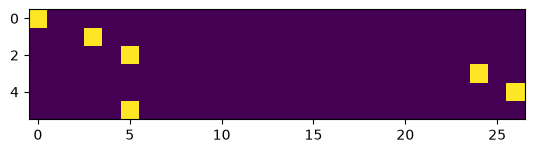

In [27]:
# We're going to 1 hot encode these integers
# where 3 => [0, 0, 0, 1, 0, 0, ...]
#       5 => [0, 0, 0, 0, 0, 1, ...]
#       0 => [1, 0, 0, 0, 0, 0, ...]
# I call these dummies

import torch.nn.functional as F
xenc = F.one_hot(xs, num_classes=27)


xenc = xenc.float() # prep the dtype for neuron
print(xenc.shape)
plt.imshow(xenc)


In [28]:
# Weights of neuron
sz = (27, 1)
W = torch.randn(sz) # normal distribution
print(f'{xenc.shape=}')
print(f'{W.shape=}')
res = xenc @ W # matrix multiply: [6,27] @ [27,1] => [6,1]
print(f'{res.shape=}')

#torch.set_printoptions(precision=4)
# these are our weights:
print(f'weights: {res}')



xenc.shape=torch.Size([6, 27])
W.shape=torch.Size([27, 1])
res.shape=torch.Size([6, 1])
weights: tensor([[-0.3096],
        [-0.8349],
        [ 1.0114],
        [ 1.9202],
        [ 1.1539],
        [ 1.0114]])


In [29]:
# lets scale to 27 neurons.
sz = (27, 27)
W = torch.randn(sz) # normal distribution
print(f'{xenc.shape=}')
print(f'{W.shape=}')
res = xenc @ W
print(f'{res.shape=}')

# these are our weights:
print(f'weights: {res}')

xenc.shape=torch.Size([6, 27])
W.shape=torch.Size([27, 27])
res.shape=torch.Size([6, 27])
weights: tensor([[-2.7741e-01, -1.6684e+00, -2.4168e-01, -7.8524e-01, -5.1769e-01,
          3.2538e-01,  1.6963e-01,  2.6495e-01, -8.4059e-01, -1.0024e+00,
          4.9358e-01,  2.3348e+00, -1.7523e+00,  9.0885e-01,  1.2092e+00,
         -4.2248e-01,  8.7615e-01,  1.0146e+00, -2.8573e-01,  8.3125e-02,
         -1.3617e+00, -1.9035e-01,  5.3544e-01, -1.8682e-02,  8.4811e-01,
          7.4583e-02,  6.1510e-01],
        [ 1.4606e+00, -2.3806e+00,  5.0463e-01, -1.5025e-01,  1.1654e-03,
          1.3000e+00,  1.7544e+00,  7.8255e-01,  2.5000e-01,  1.5229e+00,
          2.3373e-01,  1.0390e+00,  1.1137e+00,  6.1637e-02,  1.1781e+00,
          2.9643e-02,  1.2901e+00,  1.0385e+00,  8.2477e-01, -1.6656e+00,
         -7.4037e-01,  1.2964e+00,  7.5525e-01,  1.6890e-01,  5.7227e-01,
         -9.3585e-01, -1.1234e-01],
        [ 2.7396e-01,  1.4086e-02, -7.3350e-01,  1.3392e-01,  8.9311e-01,
          6.170

In [30]:
# for every one of these 27 neurons, we can get the firing rate of the input by:
print(f'{W.shape=}')
fr = (xenc @ W)[3, 13]
print(f'{fr} # the 13th neuron\'s firing rate on the 3rd input')

# its a dot product between the 3rd input and the 13th column of the W matrix.
thirdrow = xenc[3]
print(f'{thirdrow=}')
thirteenthcolumn = W[:,13]
print(f'{thirteenthcolumn=}')
dotproduct = (thirdrow * thirteenthcolumn).sum()
print(f'{dotproduct=}')

W.shape=torch.Size([27, 27])
0.9731898307800293 # the 13th neuron's firing rate on the 3rd input
thirdrow=tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0.])
thirteenthcolumn=tensor([ 0.9089,  0.5154,  1.2802,  0.0616, -0.1472,  0.6271,  2.4331,  0.0413,
        -1.4109, -0.5591, -1.3015, -0.5482, -0.4521,  0.3731, -1.8963, -1.6014,
        -0.6146,  0.5872, -0.2069,  1.8881,  1.5315, -0.0832, -0.0505, -0.4793,
         0.9732, -1.2182, -0.8508])
dotproduct=tensor(0.9732)


why do we use exp()? because negative numbers dont get output as negative, but they get output always less than 1
example:
math.exp(-3)=0.049787068367863944
math.exp(-2)=0.1353352832366127
math.exp(-1)=0.36787944117144233
math.exp(0)=1.0
math.exp(1)=2.718281828459045
math.exp(2)=7.38905609893065
math.exp(3)=20.085536923187668


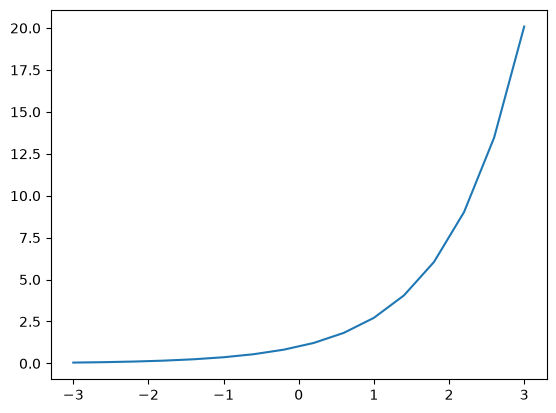

In [31]:
# interesting notes at 1:19:00 about Linear Layers:
# 27 inputs, to 27 neurons, with No bias, and No non-linearity like Tanh() === Linear layer

# We want to produce a probability distribution for the next character in the sequence.
# want to create something that is like the NxN blue plot above with noramlizes counts.
# we currently have negative and positive numbers from randn()
# but neural networks dont just magically give u probabilities that sum to 1.
# and we cant use counts because counts are positive, and integers. So not a good output for a neural net.

# therefore, our neural net will output and count with Log(counts)
# to ge counts, we will do e^log(count) -> exp(log(count))

print('why do we use exp()? because negative numbers dont get output as negative, but they get output always less than 1')
print('example:')
import math
import numpy as np
print(f'{math.exp(-3)=}')
print(f'{math.exp(-2)=}')
print(f'{math.exp(-1)=}')
print(f'{math.exp(0)=}')
print(f'{math.exp(1)=}')
print(f'{math.exp(2)=}')
print(f'{math.exp(3)=}')

x = np.linspace(-3, 3, 16)
y = [math.exp(v) for v in x]  # math.exp works on scalars only

plt.plot(x, y)

In [32]:
# (xenc @ W).exp() # exponentiate the neural net.

logits = xenc @ W # log-counts
counts = logits.exp()
print(f'{counts=}')
print(f'{counts.sum(1, keepdims=True)=}')
probs = counts / counts.sum(1, keepdims=True) # counts normalized (normalize rows in counts matrix to get probabilities)
print(f'{probs=}')

# normalizing lets us sum to 1
print(f'{probs[0].sum()=}')

counts=tensor([[ 0.7577,  0.1886,  0.7853,  0.4560,  0.5959,  1.3846,  1.1849,  1.3034,
          0.4315,  0.3670,  1.6382, 10.3276,  0.1734,  2.4815,  3.3509,  0.6554,
          2.4016,  2.7583,  0.7515,  1.0867,  0.2562,  0.8267,  1.7082,  0.9815,
          2.3352,  1.0774,  1.8498],
        [ 4.3084,  0.0925,  1.6564,  0.8605,  1.0012,  3.6693,  5.7801,  2.1871,
          1.2840,  4.5854,  1.2633,  2.8264,  3.0457,  1.0636,  3.2482,  1.0301,
          3.6331,  2.8249,  2.2814,  0.1891,  0.4769,  3.6561,  2.1282,  1.1840,
          1.7723,  0.3923,  0.8937],
        [ 1.3152,  1.0142,  0.4802,  1.1433,  2.4427,  1.8534,  1.4796,  3.2592,
          0.5152,  0.6002,  0.3308,  1.4225,  2.3957,  1.8721,  0.6272,  5.1814,
          1.0624,  0.3480,  1.6194,  0.7632,  1.9334,  0.5787,  4.7597,  0.4206,
          0.8281,  4.7462,  0.4127],
        [ 1.7674,  2.0320,  0.7500,  0.6985,  0.4032,  1.0462,  0.4760,  5.1542,
          0.5150,  1.9120,  1.8246,  0.5656,  0.4129,  2.6464,  2.0198, 

In [33]:
# what does probs[0] mean?
# from our prev example, 0/27  ==>  '.' , the dot character

# probs[0] gives us the probabilities of the next characters
# | given '.' , what are probabilities for next character

# how do we find a good W, such that the probabilities coming out are good? 
# W was the normal distribution.
# lets get on Karpathy's page...
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

In [34]:
print(f'{xs=}')
print(f'{ys=}')

xs=tensor([ 0,  3,  5, 24, 26,  5])
ys=tensor([ 3,  5, 24, 26,  5,  0])


In [35]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() 
logits = xenc @ W
counts = logits.exp()                          # SOFTMAX
probs = counts / counts.sum(1, keepdims=True)  # SOFTMAX , probs of the next char
# # last two lines are softmax function.
probs.shape

torch.Size([6, 27])

In [36]:
# Karpathy goes on a rant about how 'amateur hour' ML ppl
# end up calculating average negative log likelihood for different random
# samplings of W, by doing:
#   PARAMETER for int from 0 to 1-Billion:
#     g = torch.Generator().manual_seed(2147483647 + PARAMETER)
#     W = torch.randn((27,27), generator=g)
#
# Karpathy says its better to do good old backprop and nudge weights in opposite dir of gradient
# ... but instead loss function being mean-squared-error, we can just use neg. log likelihood. (bc its classification instead of regression)
probs[0, 3], probs[1, 5], probs[2, 23], probs[3, 26], probs[4, 5], probs[5, 0]

(tensor(0.0042, grad_fn=<SelectBackward0>),
 tensor(0.1012, grad_fn=<SelectBackward0>),
 tensor(0.0027, grad_fn=<SelectBackward0>),
 tensor(0.0562, grad_fn=<SelectBackward0>),
 tensor(0.0129, grad_fn=<SelectBackward0>),
 tensor(0.0290, grad_fn=<SelectBackward0>))

In [37]:
loss =-probs[torch.arange(len(ys)), ys].log().mean()
print(loss)

tensor(3.8281, grad_fn=<NegBackward0>)


In [38]:
# forward pass
xenc = F.one_hot(xs, num_classes=27).float() 
logits = xenc @ W
counts = logits.exp()
probs = counts / counts.sum(1, keepdims=True)
loss =-probs[torch.arange(len(ys)), ys].log().mean()

In [39]:
# backward pass
W.grad = None
loss.backward()

In [40]:
# update weights
W.data += -0.1 * W.grad

In [41]:
print(loss.item())

3.8281290531158447


In [42]:
# instead of just using 1 word in our training words[0]
print(f'{words[0]=}')
# we can now go to the moon with all the words
print(f'{words=}')

words[0]='cexze'
words=['cexze', 'momasurailezitynn', 'konimittain', 'llayn', 'ka', 'da', 'staiyaubrtthrigotai', 'moliellavo', 'ke', 'teda', 'ka', 'emimmsade', 'enkaviyny', 'ftlspihinivenvorhlasu', 'dsor', 'br', 'jol', 'pen', 'aisan', 'ja']


In [43]:
# create the dataset

path = './makemore/names.txt'
words = open(path, 'r').read().splitlines()

xs,ys = [],[]
for w in words:
    w = ['.'] + list(w) + ['.']
    for c1, c2 in zip(w, w[1:]):
        atoi_c1 = atoi[c1]
        atoi_c2 = atoi[c2]
        xs.append(atoi_c1)
        ys.append(atoi_c2)

xs = torch.tensor(xs) #inputs
ys = torch.tensor(ys) #outputs
print('number of examples: ', xs.nelement())

g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27,27), generator=g, requires_grad=True)

number of examples:  228146


In [44]:
# re-arrange for easier training

for k in range(100):
    # forward
    xenc = F.one_hot(xs, num_classes=27).float() 
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    loss =-probs[torch.arange(len(ys)), ys].log().mean()
    print(loss.item(), end=',')
    
    # backward pass
    W.grad = None
    loss.backward()
    
    # update weights
    learning_rate = 13.37
    W.data += -learning_rate * W.grad

3.758953332901001,3.641589879989624,3.5408313274383545,3.4532339572906494,3.37675404548645,3.309903144836426,3.2514026165008545,3.200052261352539,3.1547319889068604,3.1144495010375977,3.078378200531006,3.045858144760132,3.0163729190826416,2.9895148277282715,2.9649574756622314,2.942431688308716,2.9217112064361572,2.902601957321167,2.8849332332611084,2.868556499481201,2.8533401489257812,2.839167356491089,2.825934410095215,2.8135504722595215,2.8019344806671143,2.791013717651367,2.7807254791259766,2.771013021469116,2.761826515197754,2.7531208992004395,2.744856834411621,2.73699951171875,2.7295174598693848,2.7223823070526123,2.715569257736206,2.709055185317993,2.7028207778930664,2.696847677230835,2.6911184787750244,2.6856191158294678,2.680335760116577,2.6752560138702393,2.6703684329986572,2.665663003921509,2.6611297130584717,2.6567604541778564,2.6525464057922363,2.6484804153442383,2.644554853439331,2.640763998031616,2.637101173400879,2.6335606575012207,2.630136728286743,2.6268250942230225,2.

In [45]:
# 1:47:40
print('starting character, probability')
#print(list(zip(alphabet,W[0].exp().tolist()))) # what are the probabilities the starting character of a word.
for letter, prob in zip(alphabet, W[0].exp().tolist()):
    print(f"{letter}: {prob:.4f}")

# highest probability is the 1th position == 'a'
# therefore, most words start with a.
c = 13 # m
count = 0
print(f'\nafter char {c}, prob')
for letter, prob in zip(alphabet, W[c].exp().tolist()):
    print(f"{count}:{letter}: {prob:.4f}")
    count += 1


starting character, probability
.: 0.2630
a: 7.7238
b: 2.2689
c: 2.6838
d: 2.9457
e: 2.6657
f: 0.5905
g: 1.1556
h: 1.5054
i: 1.0285
j: 4.2325
k: 5.1828
l: 2.7377
m: 4.4362
n: 1.9889
o: 0.7335
p: 0.9118
q: 0.1758
r: 2.8561
s: 3.5875
t: 2.2736
u: 0.2795
v: 0.5326
w: 0.5804
x: 0.3409
y: 0.9477
z: 1.6103

after char 13, prob
0:.: 4.0708
1:a: 26.1657
2:b: 1.2317
3:c: 0.8210
4:d: 0.9659
5:e: 7.1872
6:f: 0.5794
7:g: 0.5589
8:h: 1.0482
9:i: 12.1358
10:j: 0.2476
11:k: 0.9238
12:l: 0.3773
13:m: 1.2251
14:n: 0.4414
15:o: 2.5412
16:p: 0.9760
17:q: 0.3476
18:r: 1.2728
19:s: 0.2341
20:t: 0.5110
21:u: 0.5144
22:v: 0.3769
23:w: 0.4996
24:x: 1.0245
25:y: 2.2858
26:z: 0.3793


In [46]:
# the 'gradient based framework' has an equivalent to Model Smoothing
# Old Model Smoothing meant incrementing your Probability Matrix by some positive number.
# example. P = P + 1
# New Model Smoothing, you just initialize your W weights matrix as all 0's because exp(0) == 1
# If all entries of W are 0, logits become 0, exponentiating 0's gets all 1's, then all probabilities are uniform.
# Incentivizing W to be near-0 , is equivalent to smoothing.
# In comes /Regularization/.
# Regularization: adding a small component to the loss function, to regularize the loss.
# We can use sum of all the squared weights, (W**2).sum()
# because if Weights are 0, we just get 0, but if weights are some positive number, we get higher Loss.

for k in range(100):
    # forward
    xenc = F.one_hot(xs, num_classes=27).float() 
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdims=True)
    # think of regularization as a force that wants to push W to zero 0
    regularization_func = (W**2).mean()
    regularization_strength = 0.01   # its like when we added 1 to P, P=P+1 in the 'model smoothing' cell
    regularization = regularization_strength * regularization_func
    loss =-probs[torch.arange(len(ys)), ys].log().mean() + regularization
    print(loss.item(), end=',')
    
    # backward pass
    W.grad = None
    loss.backward()
    
    # update weights
    learning_rate = 13.37
    W.data += -learning_rate * W.grad


2.5527219772338867,2.551804780960083,2.5509049892425537,2.550022840499878,2.5491578578948975,2.548308849334717,2.547475814819336,2.546658515930176,2.545856475830078,2.5450689792633057,2.5442962646484375,2.5435373783111572,2.5427920818328857,2.542060136795044,2.541341781616211,2.540635585784912,2.5399420261383057,2.5392606258392334,2.5385913848876953,2.537933111190796,2.5372865200042725,2.5366508960723877,2.5360262393951416,2.535412311553955,2.53480863571167,2.534214973449707,2.533630609512329,2.5330567359924316,2.532492160797119,2.5319366455078125,2.5313901901245117,2.5308525562286377,2.5303239822387695,2.52980375289917,2.5292916297912598,2.528787851333618,2.528291702270508,2.527803659439087,2.527323007583618,2.5268502235412598,2.5263845920562744,2.525926113128662,2.5254745483398438,2.5250303745269775,2.524592399597168,2.5241613388061523,2.5237367153167725,2.523318290710449,2.522906541824341,2.5225002765655518,2.5220999717712402,2.5217061042785645,2.521317958831787,2.520934820175171,2.

In [47]:
# how to sample from this neural net model

# OLD Re-Generating words
g = torch.Generator().manual_seed(2147483647)
wordz = []
for i in range(5):
    ix = 0
    word = ""
    while True:
        p = P[ix] # counts probabilitites
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        word += alphabet[ix]
    wordz.append(word)
print(wordz)

# NEW way to generate words
g = torch.Generator().manual_seed(2147483647)
wordz = []
for i in range(5):
    word = ""
    ix = 0
    while True:
        xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        logits = xenc @ W
        counts = logits.exp()
        p = counts / counts.sum(1, keepdims=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        if ix == 0:
            break
        word += alphabet[ix]
    wordz.append(word)
print(wordz)

['cexze', 'momasurailezitynn', 'konimittain', 'llayn', 'ka']
['cexze', 'mogllurailezityha', 'konimittain', 'llayn', 'ka']
